In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

os.chdir("..")

plt.rcParams["font.family"] = "NanumGothic"

In [2]:
df = pd.read_excel("data/HR_dataset.xlsx", engine="openpyxl")
df.head(10)

,사번,이름,채용경로,성별,나이,근속기간,출신대학,대학구분,학점,학력,...,사업장위치,본인.인지능력,본인.인내력,본인.실행력,매니저.비전,매니저.소통,매니저.실행력,직원만족도,매출액.천원,불량건수
0,4006,한경택,공채,남,39,19.5,경북대학교,국립,76.22,학사,...,일본,80,79,94,92,73,39,67.4,NaN,9.0
1,3337,임경화,공채,여,33,17.9,MICHIGAN STATE UNIVERSITY,해외,88.25,석사,...,서울(본사),74,99,82,0,10,32,35.1,163680.0,NaN
2,2543,이규경,산학,남,46,27.0,전남대학교,국립,87.67,학사,...,베트남,97,67,86,26,32,48,48.2,NaN,17.0
3,3999,윤규만,공채,남,39,19.9,인하대학교,기타,86.67,석사,...,중국,78,94,87,34,54,37,55.0,88466.0,NaN
4,1365,주강필,공채,남,32,13.9,서울대학교,top5,80.70,학사,...,일본,99,87,89,81,11,42,46.4,NaN,NaN
5,1291,최규백,공채,남,36,18.4,홍익대학교,기타,73.56,고졸,...,대전(연구소),73,79,93,26,17,14,40.3,NaN,NaN
6,5531,정경선,인턴,여,28,13.7,INDIANA UNIVERSITY-PURDUE UNIVERSITY FORT WAYNE,수도권,97.11,석사,...,대전(연구소),77,71,84,36,17,4,42.4,NaN,NaN
7,2767,조고운,산학,여,45,30.4,경북대학교,국립,68.22,박사,...,대전(연구소),92,100,77,11,12,11,39.4,NaN,10.0
8,2815,정경규,인턴,남,41,24.3,고려대학교,top5,86.00,석사,...,서울(본사),86,92,91,29,21,14,44.4,NaN,12.0
9,2884,윤가선,공채,여,44,29.2,서울대학교,top5,80.23,학사,...,베트남,88,97,80,93,74,47,67.1,NaN,10.0


In [ ]:
# pylint: disable=invalid-name
target = "성과점수"

features = [
    "성별",
    "나이",
    "근속기간",
    "대학구분",
    "학점",
    "학력",
    "입사년도",
    "직군",
    "팀구분",
    "잔업시간",
    "미사용.휴가일수",
    "연봉",
    "사업장위치",
    "본인.인지능력",
    "본인.인내력",
    "본인.실행력",
    "매니저.비전",
    "매니저.소통",
    "매니저.실행력",
    "직원만족도",
]

X = df[features]
y = df[target]

# Missing Value filtering
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

# One Hot Encording
categorical_features = X.select_dtypes(include=["object"]).columns
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Random Forest
model = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))]
)

In [ ]:
# train 80%, test 20%
# pylint: disable=invalid-name
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit & Predict
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Root Mean Squared Error (RMSE): 8.93
R^2 Score: 0.55


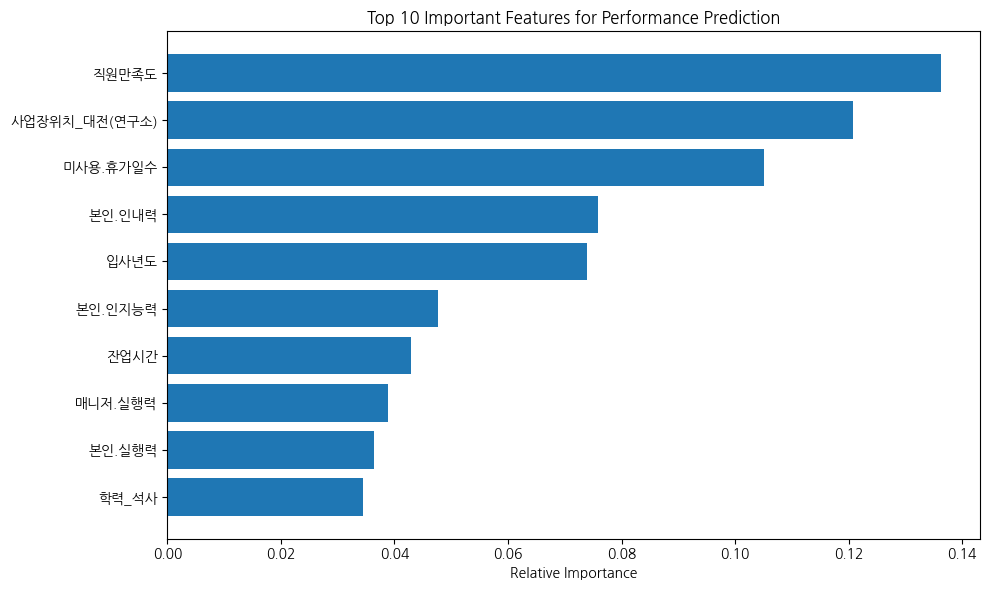

In [5]:
# Feature Importance
ohe_feature_names = (
    model.named_steps["preprocessor"]
    .transformers_[1][1]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)
all_feature_names = np.concatenate([numeric_features, ohe_feature_names])

importances = model.named_steps["regressor"].feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10

plt.figure(figsize=(10, 6))
plt.title("Top 10 Important Features for Performance Prediction")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [all_feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()